# VLAv3 Research Notebook (Colab T4 Ready)

This notebook implements and compares four Transformer variants:
1. **Softmax causal attention**
2. **Linear attention (ELU+1)**
3. **DeltaNet-style recurrent attention**
4. **VLAv3 recurrent attention**

It also runs the three requested experiments with detailed logging and paper-grade plots:
- **Experiment 1 — Scaling behavior** (forward time + tokens/sec vs sequence length)
- **Experiment 2 — Stability behavior** (track $\|S_t\|$ and $\|A_t\|$ over time)
- **Experiment 3 — Behavior comparison** (associative retrieval accuracy vs length)

In [1]:
# ===== 0) Environment + reproducibility =====
import os, math, time, json, random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.float32

ROOT = Path('/content' if Path('/content').exists() else '.')
OUT = ROOT / 'vlav3_paper_artifacts'
OUT.mkdir(parents=True, exist_ok=True)
(OUT / 'plots').mkdir(exist_ok=True)
(OUT / 'logs').mkdir(exist_ok=True)

print('Device:', DEVICE)
print('Torch :', torch.__version__)
print('Out   :', OUT)

Device: cuda
Torch : 2.10.0+cu128
Out   : /content/vlav3_paper_artifacts


In [2]:
# ===== 1) Config =====
@dataclass
class ModelConfig:
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 2
    d_ff: int = 256
    dropout: float = 0.0
    vocab_size: int = 128
    max_seq_len: int = 4096

@dataclass
class TrainConfig:
    batch_size: int = 32
    steps: int = 400
    lr: float = 3e-4
    weight_decay: float = 1e-2
    grad_clip: float = 1.0
    log_every: int = 20

In [3]:
# ===== 2) Attention implementations =====

def _split_heads(x, n_heads):
    B, T, D = x.shape
    H = n_heads
    Dh = D // H
    return x.view(B, T, H, Dh).transpose(1, 2)  # B,H,T,Dh

def _merge_heads(x):
    B, H, T, Dh = x.shape
    return x.transpose(1, 2).contiguous().view(B, T, H * Dh)

class SoftmaxCausalAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, need_state=False):
        B, T, D = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)
        q, k, v = _split_heads(q, self.n_heads), _split_heads(k, self.n_heads), _split_heads(v, self.n_heads)
        scale = 1.0 / math.sqrt(q.shape[-1])
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float('-inf'))
        p = F.softmax(scores, dim=-1)
        p = self.drop(p)
        y = torch.matmul(p, v)
        y = _merge_heads(y)
        y = self.o(y)
        if need_state:
            # Softmax has no recurrent S/A states
            return y, {'S_norm': None, 'A_norm': None}
        return y

class LinearAttention(nn.Module):
    """Causal linear attention with ELU+1 features."""
    def __init__(self, d_model, n_heads, eps=1e-6):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads, self.eps = d_model, n_heads, eps
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)

    def forward(self, x, need_state=False):
        B, T, D = x.shape
        H = self.n_heads
        Dh = D // H

        q = F.elu(_split_heads(self.q(x), H)) + 1.0
        k = F.elu(_split_heads(self.k(x), H)) + 1.0
        v = _split_heads(self.v(x), H)

        S = torch.zeros(B, H, Dh, Dh, device=x.device, dtype=x.dtype)
        z = torch.zeros(B, H, Dh, device=x.device, dtype=x.dtype)

        ys = []
        S_norm = []
        for t in range(T):
            kt = k[:, :, t, :]
            vt = v[:, :, t, :]
            qt = q[:, :, t, :]
            S = S + torch.einsum('bhd,bhe->bhde', vt, kt)
            z = z + kt
            yt = torch.einsum('bhde,bhe->bhd', S, qt)
            den = torch.einsum('bhd,bhd->bh', z, qt).unsqueeze(-1).clamp(min=self.eps)
            ys.append(yt / den)
            if need_state:
                S_norm.append(S.norm(dim=(-2,-1)).mean().item())

        y = torch.stack(ys, dim=2)
        y = _merge_heads(y)
        y = self.o(y)
        if need_state:
            return y, {'S_norm': S_norm, 'A_norm': None}
        return y

class DeltaNetAttention(nn.Module):
    """Simple DeltaNet-style recurrent fast-weight update with learned gate."""
    def __init__(self, d_model, n_heads, eps=1e-6):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads, self.eps = d_model, n_heads, eps
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.g = nn.Linear(d_model, d_model)  # gate
        self.o = nn.Linear(d_model, d_model)

    def forward(self, x, need_state=False):
        B, T, D = x.shape
        H = self.n_heads
        Dh = D // H

        q = F.elu(_split_heads(self.q(x), H)) + 1.0
        k = F.elu(_split_heads(self.k(x), H)) + 1.0
        v = _split_heads(self.v(x), H)
        g = torch.sigmoid(_split_heads(self.g(x), H))

        S = torch.zeros(B, H, Dh, Dh, device=x.device, dtype=x.dtype)
        A = torch.zeros(B, H, Dh, Dh, device=x.device, dtype=x.dtype)

        ys, S_norm, A_norm = [], [], []
        for t in range(T):
            kt = k[:, :, t, :]
            vt = v[:, :, t, :]
            qt = q[:, :, t, :]
            gt = g[:, :, t, :]

            delta = torch.einsum('bhd,bhe->bhde', vt, kt)
            S = gt.unsqueeze(-1) * S + delta
            A = 0.99 * A + torch.einsum('bhd,bhe->bhde', kt, kt)

            yt = torch.einsum('bhde,bhe->bhd', S, qt)
            den = torch.einsum('bhde,bhd,bhe->bh', A + torch.eye(Dh, device=x.device).view(1,1,Dh,Dh)*1e-3, qt, qt).unsqueeze(-1)
            ys.append(yt / den.clamp(min=self.eps))

            if need_state:
                S_norm.append(S.norm(dim=(-2,-1)).mean().item())
                A_norm.append(A.norm(dim=(-2,-1)).mean().item())

        y = torch.stack(ys, dim=2)
        y = _merge_heads(y)
        y = self.o(y)
        if need_state:
            return y, {'S_norm': S_norm, 'A_norm': A_norm}
        return y

class VLAv3Attention(nn.Module):
    """Stable VLAv3-style recurrent update with normalized alpha and key."""
    def __init__(self, d_model, n_heads, lambda_0=10.0, stab_eps=1e-5):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.lambda_0, self.stab_eps = lambda_0, stab_eps
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.u = nn.Linear(d_model, d_model, bias=False)
        self.o = nn.Linear(d_model, d_model)

    def forward(self, x, need_state=False):
        B, T, D = x.shape
        H = self.n_heads
        Dh = D // H

        q = F.elu(_split_heads(self.q(x), H)) + 1.0
        k_raw = _split_heads(self.k(x), H)
        k = F.elu(k_raw) + 1.0
        v = _split_heads(self.v(x), H)
        u = F.normalize(_split_heads(self.u(x), H), p=2, dim=-1)

        eye = torch.eye(Dh, device=x.device, dtype=x.dtype).view(1,1,Dh,Dh)
        A = (1.0 / self.lambda_0) * eye.repeat(B, H, 1, 1)
        S = torch.zeros(B, H, Dh, Dh, device=x.device, dtype=x.dtype)

        ys, S_norm, A_norm = [], [], []
        for t in range(T):
            ut = u[:, :, t, :] / math.sqrt(Dh)
            z = torch.einsum('bhde,bhe->bhd', A, ut)
            dot = torch.einsum('bhd,bhd->bh', ut, z)
            delta = (1.0 + dot).clamp(min=self.stab_eps)
            A = A - torch.einsum('bhd,bhe->bhde', z, z) / delta.unsqueeze(-1).unsqueeze(-1)

            kt = F.normalize(k[:, :, t, :], p=2, dim=-1)
            alpha = torch.einsum('bhde,bhe->bhd', A, kt)
            alpha = F.normalize(alpha, p=2, dim=-1)
            vt = v[:, :, t, :]

            pred = torch.einsum('bhde,bhe->bhd', S, kt)
            err = vt - pred
            S = S + torch.einsum('bhd,bhe->bhde', err, alpha)

            qt = q[:, :, t, :]
            num = torch.einsum('bhde,bhe->bhd', S, qt)
            den = torch.einsum('bhde,bhd,bhe->bh', A, qt, qt).unsqueeze(-1).clamp(min=self.stab_eps)
            ys.append(num / den)

            if need_state:
                S_norm.append(S.norm(dim=(-2,-1)).mean().item())
                A_norm.append(A.norm(dim=(-2,-1)).mean().item())

        y = torch.stack(ys, dim=2)
        y = _merge_heads(y)
        y = self.o(y)
        if need_state:
            return y, {'S_norm': S_norm, 'A_norm': A_norm}
        return y

In [4]:
# ===== 3) Transformer stack with pluggable attention =====

ATTN_REGISTRY = {
    'softmax': SoftmaxCausalAttention,
    'linear': LinearAttention,
    'deltanet': DeltaNetAttention,
    'vla': VLAv3Attention,
}

class TransformerBlock(nn.Module):
    def __init__(self, cfg: ModelConfig, attn_type: str):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.attn = ATTN_REGISTRY[attn_type](cfg.d_model, cfg.n_heads, dropout=cfg.dropout) if attn_type=='softmax' else ATTN_REGISTRY[attn_type](cfg.d_model, cfg.n_heads)
        self.ff = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff),
            nn.GELU(),
            nn.Linear(cfg.d_ff, cfg.d_model),
        )

    def forward(self, x, need_state=False):
        if need_state:
            y, st = self.attn(self.ln1(x), need_state=True)
            x = x + y
            x = x + self.ff(self.ln2(x))
            return x, st
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class TinyTransformerLM(nn.Module):
    def __init__(self, cfg: ModelConfig, attn_type: str):
        super().__init__()
        self.cfg = cfg
        self.token = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos = nn.Embedding(cfg.max_seq_len, cfg.d_model)
        self.blocks = nn.ModuleList([TransformerBlock(cfg, attn_type) for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.head.weight = self.token.weight

    def forward(self, idx, need_state=False):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.token(idx) + self.pos(pos)
        state = None
        for i, block in enumerate(self.blocks):
            if need_state and i == len(self.blocks) - 1:
                x, state = block(x, need_state=True)
            else:
                x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits, state

In [5]:
# ===== 4) Synthetic associative retrieval task =====

def make_associative_batch(batch_size: int, seq_len: int, vocab_size: int, n_pairs: int, device: str):
    """
    Format per sample (length = 2*n_pairs + 1 + n_queries):
      k1 v1 k2 v2 ... <sep> q1 q2 ...
    Targets only at query positions: corresponding values.
    """
    sep = vocab_size - 1
    n_queries = seq_len - (2*n_pairs + 1)
    assert n_queries > 0

    x = torch.full((batch_size, seq_len), sep, dtype=torch.long, device=device)
    y = torch.full((batch_size, seq_len), -100, dtype=torch.long, device=device)

    for b in range(batch_size):
        keys = torch.randperm(vocab_size - 1, device=device)[:n_pairs]
        vals = torch.randint(0, vocab_size - 1, (n_pairs,), device=device)
        for i in range(n_pairs):
            x[b, 2*i] = keys[i]
            x[b, 2*i + 1] = vals[i]
        x[b, 2*n_pairs] = sep

        q_idx = torch.randint(0, n_pairs, (n_queries,), device=device)
        q_keys = keys[q_idx]
        q_vals = vals[q_idx]
        x[b, 2*n_pairs + 1:] = q_keys
        y[b, 2*n_pairs + 1:] = q_vals
    return x, y

@torch.no_grad()
def eval_assoc_accuracy(model, seq_len, cfg, n_pairs=16, batches=20):
    model.eval()
    all_acc = []
    for _ in range(batches):
        x, y = make_associative_batch(cfg.batch_size, seq_len, model.cfg.vocab_size, n_pairs, DEVICE)
        logits, _ = model(x)
        pred = logits.argmax(-1)
        mask = y != -100
        acc = (pred[mask] == y[mask]).float().mean().item()
        all_acc.append(acc)
    return float(np.mean(all_acc))

In [6]:
# ===== 5) Training + logging helpers =====

def train_assoc_model(attn_type: str, mcfg: ModelConfig, tcfg: TrainConfig, seq_len: int, n_pairs: int = 16):
    model = TinyTransformerLM(mcfg, attn_type).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=tcfg.lr, weight_decay=tcfg.weight_decay)

    logs = []
    model.train()
    t0 = time.time()
    for step in range(1, tcfg.steps + 1):
        x, y = make_associative_batch(tcfg.batch_size, seq_len, mcfg.vocab_size, n_pairs, DEVICE)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.view(-1, mcfg.vocab_size), y.view(-1), ignore_index=-100)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg.grad_clip)
        opt.step()

        with torch.no_grad():
            pred = logits.argmax(-1)
            mask = y != -100
            acc = (pred[mask] == y[mask]).float().mean().item()

        if step % tcfg.log_every == 0 or step == 1 or step == tcfg.steps:
            row = {
                'attn_type': attn_type,
                'step': step,
                'loss': float(loss.item()),
                'train_acc': float(acc),
                'elapsed_sec': float(time.time() - t0),
            }
            logs.append(row)
            print(f"[{attn_type:8s}] step={step:4d} loss={row['loss']:.4f} acc={row['train_acc']:.4f} elapsed={row['elapsed_sec']:.1f}s")

    return model, pd.DataFrame(logs)


def benchmark_forward(model, seq_len, batch_size=8, warmup=10, iters=30):
    model.eval()
    x = torch.randint(0, model.cfg.vocab_size, (batch_size, seq_len), device=DEVICE)

    for _ in range(warmup):
        _ = model(x)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(iters):
        _ = model(x)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    sec = (t1 - t0) / iters
    toks_per_sec = (batch_size * seq_len) / max(sec, 1e-9)
    return sec, toks_per_sec

In [7]:
# ===== 6) Experiment 1 — scaling =====

SEQ_LENS = [256, 512, 1024, 2048]
MODEL_TYPES = ['softmax', 'linear', 'deltanet', 'vla']

mcfg = ModelConfig(d_model=128, n_heads=4, n_layers=2, d_ff=256, vocab_size=128, max_seq_len=max(SEQ_LENS))

scaling_rows = []
for name in MODEL_TYPES:
    model = TinyTransformerLM(mcfg, name).to(DEVICE)
    for L in SEQ_LENS:
        fwd_sec, tps = benchmark_forward(model, seq_len=L, batch_size=8, warmup=10, iters=40)
        row = {
            'model': name,
            'seq_len': L,
            'forward_sec': fwd_sec,
            'tokens_per_sec': tps,
        }
        scaling_rows.append(row)
        print(f"[scaling] model={name:8s} L={L:4d} time={fwd_sec*1e3:8.3f} ms  tok/s={tps:10.1f}")

scaling_df = pd.DataFrame(scaling_rows)
scaling_df.to_csv(OUT / 'logs' / 'exp1_scaling.csv', index=False)
scaling_df.head()

[scaling] model=softmax  L= 256 time=   5.238 ms  tok/s=  390990.1
[scaling] model=softmax  L= 512 time=   5.444 ms  tok/s=  752432.4
[scaling] model=softmax  L=1024 time=  15.646 ms  tok/s=  523584.9
[scaling] model=softmax  L=2048 time=  55.973 ms  tok/s=  292711.8
[scaling] model=linear   L= 256 time= 202.439 ms  tok/s=   10116.6
[scaling] model=linear   L= 512 time= 397.148 ms  tok/s=   10313.5
[scaling] model=linear   L=1024 time= 810.263 ms  tok/s=   10110.3
[scaling] model=linear   L=2048 time=1530.510 ms  tok/s=   10704.9
[scaling] model=deltanet L= 256 time= 466.068 ms  tok/s=    4394.2
[scaling] model=deltanet L= 512 time= 969.250 ms  tok/s=    4225.9
[scaling] model=deltanet L=1024 time=1878.075 ms  tok/s=    4361.9
[scaling] model=deltanet L=2048 time=3754.106 ms  tok/s=    4364.3
[scaling] model=vla      L= 256 time= 811.892 ms  tok/s=    2522.5
[scaling] model=vla      L= 512 time=1528.986 ms  tok/s=    2678.9
[scaling] model=vla      L=1024 time=3022.981 ms  tok/s=    27

,model,seq_len,forward_sec,tokens_per_sec
0,softmax,256,0.005238,390990.102729
1,softmax,512,0.005444,752432.368287
2,softmax,1024,0.015646,523584.870756
3,softmax,2048,0.055973,292711.757201
4,linear,256,0.202439,10116.642432


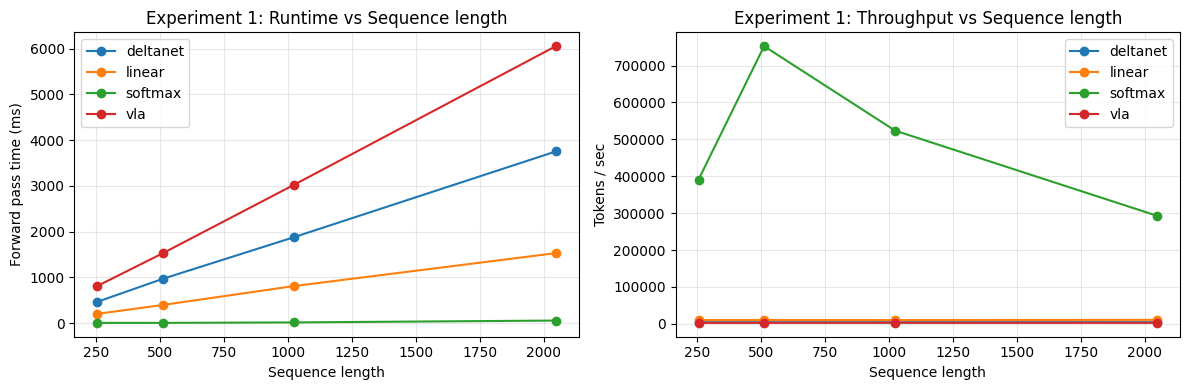

In [8]:
# Plot Experiment 1
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for m, g in scaling_df.groupby('model'):
    plt.plot(g['seq_len'], g['forward_sec']*1e3, marker='o', label=m)
plt.xlabel('Sequence length')
plt.ylabel('Forward pass time (ms)')
plt.title('Experiment 1: Runtime vs Sequence length')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
for m, g in scaling_df.groupby('model'):
    plt.plot(g['seq_len'], g['tokens_per_sec'], marker='o', label=m)
plt.xlabel('Sequence length')
plt.ylabel('Tokens / sec')
plt.title('Experiment 1: Throughput vs Sequence length')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(OUT / 'plots' / 'exp1_scaling.png', dpi=220)
plt.show()

In [9]:
# ===== 7) Experiment 2 — stability =====

STAB_LEN = 2048
x = torch.randint(0, mcfg.vocab_size, (4, STAB_LEN), device=DEVICE)

stab_rows = []
for name in MODEL_TYPES:
    model = TinyTransformerLM(mcfg, name).to(DEVICE).eval()
    with torch.no_grad():
        _, st = model(x, need_state=True)
    S_norm = st['S_norm'] if st is not None else None
    A_norm = st['A_norm'] if st is not None else None

    if S_norm is None:
        # preserve row format for paper tables
        for t in range(STAB_LEN):
            stab_rows.append({'model': name, 't': t+1, 'S_norm': np.nan, 'A_norm': np.nan})
    else:
        for t, s in enumerate(S_norm, start=1):
            a = np.nan if A_norm is None else A_norm[t-1]
            stab_rows.append({'model': name, 't': t, 'S_norm': s, 'A_norm': a})

stability_df = pd.DataFrame(stab_rows)
stability_df.to_csv(OUT / 'logs' / 'exp2_stability.csv', index=False)
stability_df.head()

,model,t,S_norm,A_norm
0,softmax,1,NaN,NaN
1,softmax,2,NaN,NaN
2,softmax,3,NaN,NaN
3,softmax,4,NaN,NaN
4,softmax,5,NaN,NaN


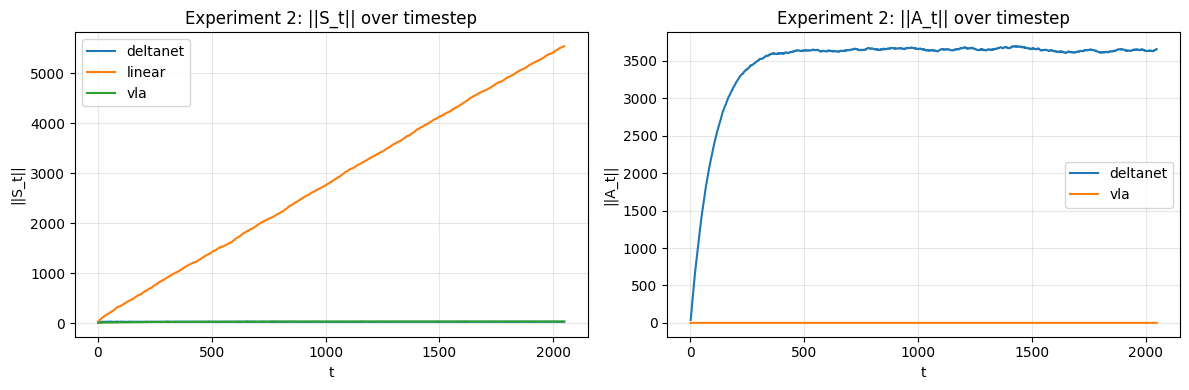

In [10]:
# Plot Experiment 2
fig, axes = plt.subplots(1, 2, figsize=(12,4))

for m, g in stability_df.groupby('model'):
    if g['S_norm'].notna().any():
        axes[0].plot(g['t'], g['S_norm'], label=m)
axes[0].set_title('Experiment 2: ||S_t|| over timestep')
axes[0].set_xlabel('t')
axes[0].set_ylabel('||S_t||')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for m, g in stability_df.groupby('model'):
    if g['A_norm'].notna().any():
        axes[1].plot(g['t'], g['A_norm'], label=m)
axes[1].set_title('Experiment 2: ||A_t|| over timestep')
axes[1].set_xlabel('t')
axes[1].set_ylabel('||A_t||')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'plots' / 'exp2_stability.png', dpi=220)
plt.show()

In [11]:
# ===== 8) Experiment 3 — behavior comparison (associative retrieval) =====

EVAL_LENS = [256, 512, 1024]
TRAIN_LEN = 256

train_cfg = TrainConfig(batch_size=32, steps=300, lr=3e-4, log_every=25)

behavior_rows = []
train_logs = {}
for name in MODEL_TYPES:
    model, log_df = train_assoc_model(name, mcfg, train_cfg, seq_len=TRAIN_LEN, n_pairs=16)
    train_logs[name] = log_df
    log_df.to_csv(OUT / 'logs' / f'exp3_trainlog_{name}.csv', index=False)

    for L in EVAL_LENS:
        acc = eval_assoc_accuracy(model, seq_len=L, cfg=train_cfg, n_pairs=16, batches=25)
        behavior_rows.append({'model': name, 'seq_len': L, 'accuracy': acc})
        print(f"[behavior] model={name:8s} eval_len={L:4d} acc={acc:.4f}")

behavior_df = pd.DataFrame(behavior_rows)
behavior_df.to_csv(OUT / 'logs' / 'exp3_behavior.csv', index=False)
behavior_df.head()

[softmax ] step=   1 loss=85.8063 acc=0.0119 elapsed=0.5s
[softmax ] step=  25 loss=66.0487 acc=0.0035 elapsed=1.4s
[softmax ] step=  50 loss=20.7405 acc=0.0115 elapsed=2.3s
[softmax ] step=  75 loss=10.3278 acc=0.0098 elapsed=3.2s
[softmax ] step= 100 loss=7.4117 acc=0.0038 elapsed=4.2s
[softmax ] step= 125 loss=6.2010 acc=0.0045 elapsed=5.3s
[softmax ] step= 150 loss=5.6174 acc=0.0133 elapsed=6.5s
[softmax ] step= 175 loss=5.2504 acc=0.0074 elapsed=7.4s
[softmax ] step= 200 loss=5.1942 acc=0.0032 elapsed=8.3s
[softmax ] step= 225 loss=5.0399 acc=0.0108 elapsed=9.2s
[softmax ] step= 250 loss=4.9597 acc=0.0043 elapsed=10.2s
[softmax ] step= 275 loss=4.9632 acc=0.0067 elapsed=11.1s
[softmax ] step= 300 loss=4.9280 acc=0.0069 elapsed=12.0s
[behavior] model=softmax  eval_len= 256 acc=0.0079
[behavior] model=softmax  eval_len= 512 acc=0.0078
[behavior] model=softmax  eval_len=1024 acc=0.0077
[linear  ] step=   1 loss=85.6584 acc=0.0017 elapsed=0.7s
[linear  ] step=  25 loss=64.5548 acc=0.0

,model,seq_len,accuracy
0,softmax,256,0.007853
1,softmax,512,0.007779
2,softmax,1024,0.007685
3,linear,256,0.007012
4,linear,512,0.008108


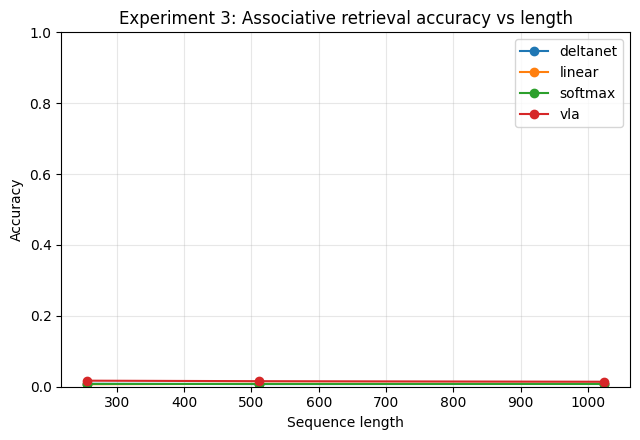

In [12]:
# Plot Experiment 3
plt.figure(figsize=(6.5,4.5))
for m, g in behavior_df.groupby('model'):
    plt.plot(g['seq_len'], g['accuracy'], marker='o', label=m)
plt.xlabel('Sequence length')
plt.ylabel('Accuracy')
plt.title('Experiment 3: Associative retrieval accuracy vs length')
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'plots' / 'exp3_behavior.png', dpi=220)
plt.show()

In [13]:
# ===== 9) Paper-ready summary tables + JSON export =====

summary = {
    'device': DEVICE,
    'seed': SEED,
    'model_config': asdict(mcfg),
    'train_config': asdict(train_cfg),
    'experiment_1_scaling': scaling_df.to_dict(orient='records'),
    'experiment_2_stability_tail': (
        stability_df.groupby('model')[['S_norm','A_norm']].tail(1).to_dict(orient='records')
    ),
    'experiment_3_behavior': behavior_df.to_dict(orient='records'),
}

with open(OUT / 'logs' / 'paper_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved:')
print('-', OUT / 'plots' / 'exp1_scaling.png')
print('-', OUT / 'plots' / 'exp2_stability.png')
print('-', OUT / 'plots' / 'exp3_behavior.png')
print('-', OUT / 'logs' / 'paper_summary.json')

Saved:
- /content/vlav3_paper_artifacts/plots/exp1_scaling.png
- /content/vlav3_paper_artifacts/plots/exp2_stability.png
- /content/vlav3_paper_artifacts/plots/exp3_behavior.png
- /content/vlav3_paper_artifacts/logs/paper_summary.json


## Notes for Colab-T4 runs

- Keep `d_model=128`, `n_layers=2` for quick iteration.
- For publication-quality runs:
  - Increase benchmark repetitions (`iters`) in Experiment 1.
  - Increase training steps in Experiment 3 (e.g., 2k–10k).
  - Run 3 seeds and report mean ± std.
- This notebook already exports CSV logs and PNG plots to `vlav3_paper_artifacts/`.